# A PDE-constrained inverse problem: imaging conductivity from boundary measurements

Current is injected at one electrode at a time on the boundary of a conducting body, and the
potential is measured at the others. The goal is to recover the conductivity $\sigma(x)$ inside.
This is the setting of electrical impedance tomography and of DC resistivity surveys in
geophysics. Steady heat conduction with thermocouples on the boundary gives the same maths.
For each source $f_k$,

$$
-\nabla\cdot\big(\sigma \nabla u_k\big) = f_k \ \text{ in } \Omega, \qquad u_k = 0 \text{ on the grounded bottom edge},
\qquad \sigma\, \partial_n u_k = 0 \text{ elsewhere}.
$$

With $m = \log\sigma$ on the grid, the finite-volume stiffness matrix $K(m)$ and the sampling
operator $P$, the reconstruction is the regularized least-squares problem

$$
\min_m \ \Phi(m) = \frac12 \sum_k \big\| (P u_k(m) - d_k)/\varepsilon \big\|^2 + \frac\alpha2 \|\nabla_h m\|^2,
\qquad K(m)\, u_k = f_k .
$$

What Scaly contributes:

- **One factorization, many right-hand sides.** All the sources share $K(m)$. `SparseLDL` factors
  it once, and each source is one more pair of triangular sweeps with the same factor.
- **Adjoints for free.** Reverse mode through the solve uses its implicit rule, which is the adjoint
  equation $K^\top \lambda_k = -P^\top r_k$. The gradient therefore costs one more solve with the
  same factor, and nobody derives it by hand.
- **Second order too.** Forward mode over the gradient gives exact Hessian–vector products, a few
  solves each. They drive a Newton–Krylov method, which converges in far fewer iterations than
  L-BFGS.

| Scaly feature | Where |
| --- | --- |
| `SparseMatrix.from_coo` with values from `sc.gather`/`sc.segment_sum` | assembly of $K(m)$ on a fixed pattern |
| `linalg.SparseLDL`, one factorization reused by every `.solve` | all sources with one factorization |
| `sc.gradient`, `sc.jvp` of the gradient | adjoint gradient, Hessian–vector products |

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize, sparse
from scipy.sparse import linalg as splinalg

import plotstyle
import scaly as sc
from scaly import linalg
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "conductivity_inversion"
rng = np.random.default_rng(11)

## Grid, electrodes and the true body

The grid has $n \times n$ nodes on the unit square. The bottom row is grounded and eliminated, and
the other nodes are unknowns. Electrodes sit on the top edge and on the two sides. Each experiment
injects a unit current at one of thirteen of them. The body is uniform ($\sigma = 1$) apart from a
conductive inclusion ($\sigma = 5$) and a resistive one ($\sigma = 0.2$).

In [2]:
N = 32
H = 1.0 / (N - 1)
FREE = N * (N - 1)  # rows 1..N-1 of the grid; row 0 is grounded
ij = np.array([(i, j) for i in range(1, N) for j in range(N)])  # (row, column) of each unknown
XY = np.column_stack([ij[:, 1] * H, ij[:, 0] * H])
node = -np.ones((N, N), dtype=int)
node[1:, :] = np.arange(FREE).reshape(N - 1, N)

# faces between two unknowns, and faces from row 1 down to the grounded row
FACE_P = np.r_[node[1:, :-1].ravel(), node[1:-1, :].ravel()]
FACE_Q = np.r_[node[1:, 1:].ravel(), node[2:, :].ravel()]
GROUNDED = node[1, :]

top = node[N - 1, :]
left, right = node[1:-1, 0], node[1:-1, N - 1]
ELECTRODES = np.r_[top[::3], left[::6], right[::6]]
SOURCES = np.r_[top[1::5], left[3::10], right[3::10]]
N_SRC, N_MEAS = len(SOURCES), len(ELECTRODES)
F = np.zeros((FREE, N_SRC))
F[SOURCES, np.arange(N_SRC)] = 1.0

blob = lambda c, r: np.exp(-np.sum((XY - c) ** 2, axis=1) / (2 * r**2))
M_TRUE = np.log(1.0 + 4.0 * (blob((0.32, 0.55), 0.08) > 0.5)) + np.log(1.0 - 0.8 * (blob((0.68, 0.4), 0.09) > 0.5))
print(f"{FREE} unknowns per solve, {N_SRC} sources, {N_MEAS} electrodes: {N_SRC * N_MEAS} measurements for {FREE} conductivity values")

992 unknowns per solve, 13 sources, 21 electrodes: 273 measurements for 992 conductivity values


## Assembly and the forward model

A face conducts with the arithmetic mean of $\sigma = e^m$ at its two nodes. Its conductance goes
off the diagonal, and it is summed into both diagonals with `segment_sum`. Only the lower triangle
is stored, which is what `SparseLDL` reads. `forward` factors $K(m)$ once and solves for each of
the thirteen sources with that factor.

forward model against SciPy spsolve: 1.8e-11


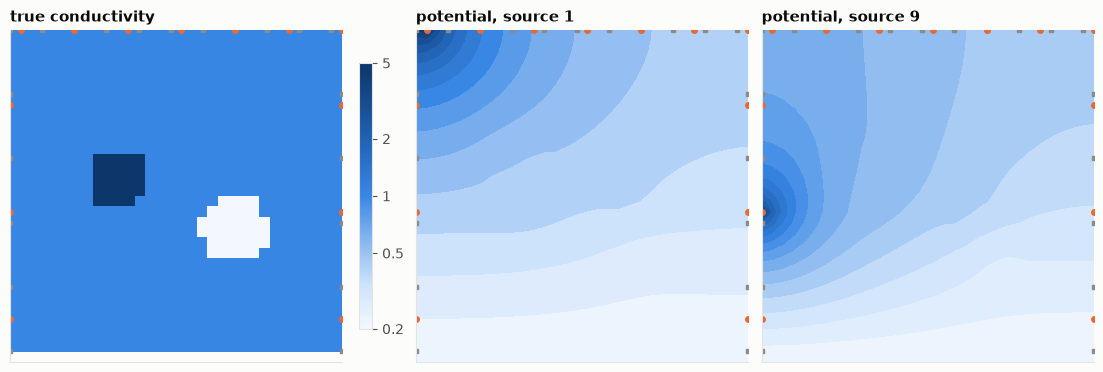

In [3]:
def assemble(m):
  s = m.exp()
  k_face = 0.5 * (sc.gather(s, FACE_P) + sc.gather(s, FACE_Q))
  k_ground = sc.gather(s, GROUNDED)
  diag = sc.segment_sum(sc.concat([k_face, k_face, k_ground]), np.r_[FACE_P, FACE_Q, GROUNDED], FREE)
  rows, cols = np.r_[np.arange(FREE), np.maximum(FACE_P, FACE_Q)], np.r_[np.arange(FREE), np.minimum(FACE_P, FACE_Q)]
  return linalg.SparseMatrix.from_coo(rows, cols, sc.concat([diag, -k_face]), (FREE, FREE))


def predictions(m):
  """The potential at every electrode for every source, source by source."""
  fact = linalg.SparseLDL(assemble(m), name="stiffness")
  return sc.concat([sc.gather(fact.solve(sc.const(F[:, k] / H**2)), ELECTRODES) for k in range(N_SRC)])


@sc.function(sc.L("m", FREE), sc.L("d", ...))
def forward(m):
  return predictions(m)


def stiffness_np(m):
  """The same matrix, assembled independently with SciPy (both triangles)."""
  s = np.exp(m)
  kf = 0.5 * (s[FACE_P] + s[FACE_Q])
  diag = np.bincount(np.r_[FACE_P, FACE_Q, GROUNDED], np.r_[kf, kf, s[GROUNDED]], FREE)
  off = sparse.coo_array((-kf, (FACE_P, FACE_Q)), shape=(FREE, FREE))
  return sparse.csc_array(sparse.diags_array(diag) + off + off.T)


def reference_forward(m):
  u = splinalg.spsolve(stiffness_np(m), F / H**2)
  return u[ELECTRODES].T.ravel()


d_clean = forward(M_TRUE)
print(f"forward model against SciPy spsolve: {np.abs(d_clean - reference_forward(M_TRUE)).max():.1e}")
NOISE = 0.01 * np.abs(d_clean).mean()
d_obs = d_clean + NOISE * rng.standard_normal(d_clean.size)


def field(values):
  """Unknowns back onto the full grid, with the grounded row."""
  grid = np.zeros((N, N))
  grid[1:, :] = values.reshape(N - 1, N)
  return grid


u_true = splinalg.spsolve(stiffness_np(M_TRUE), F / H**2)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
image = axes[0].imshow(field(np.exp(M_TRUE)), origin="lower", extent=(0, 1, 0, 1), cmap=plotstyle.BLUES, norm="log")
bar = fig.colorbar(image, ax=axes[0], shrink=0.8, ticks=[0.2, 0.5, 1, 2, 5])
bar.ax.set_yticklabels(["0.2", "0.5", "1", "2", "5"])
bar.ax.minorticks_off()
axes[0].set_title("true conductivity")
grid_x, grid_y = np.meshgrid(np.linspace(0, 1, N), np.linspace(0, 1, N))
for ax, k in zip(axes[1:], (0, 8)):
  ax.contourf(grid_x, grid_y, field(u_true[:, k]), levels=20, cmap=plotstyle.BLUES)
  ax.set_title(f"potential, source {k + 1}")
for ax in axes:
  ax.plot(*XY[ELECTRODES].T, "s", ms=3, color=plotstyle.NEUTRAL)
  ax.plot(*XY[SOURCES].T, "o", ms=4, color=plotstyle.ORANGE)
  ax.set_aspect("equal")
  ax.grid(False)
  ax.set_xticks([])
  ax.set_yticks([])
plt.show()

## Objective, gradient and Hessian–vector product

The regularizer penalizes differences of $m$ across faces, a graph Laplacian on the grid.
`objective` returns $\Phi$, $\nabla\Phi$ and the data misfit from one forward and one reverse sweep.
`hvp` differentiates the gradient once more, in a direction $v$. Both are checked against
central differences.

In [4]:
ALPHA = 2.0
m_s, v_s, d_s = sc.sym("m", FREE), sc.sym("v", FREE), sc.sym("d_obs", N_MEAS * N_SRC)


def phi(m, d):
  r = (predictions(m) - d) / NOISE
  smooth = sc.gather(m, FACE_P) - sc.gather(m, FACE_Q)
  return 0.5 * sc.sumsqr(r) + 0.5 * ALPHA * sc.sumsqr(smooth), 0.5 * sc.sumsqr(r)


value, misfit = phi(m_s, d_s)
grad = sc.gradient(value, m_s)
objective = sc.Function._from_exprs("objective", [m_s, d_s], [value, grad, misfit], ["m", "d_obs"], ["phi", "grad", "misfit"])
hvp = sc.Function._from_exprs("hvp", [m_s, d_s, v_s], [sc.jvp(grad, m_s, v_s)], ["m", "d_obs", "v"], ["Hv"])

m0 = np.zeros(FREE)
f0, g0, _ = objective((m0, d_obs))
direction = rng.standard_normal(FREE)
fd = (objective((m0 + 1e-5 * direction, d_obs))[0] - objective((m0 - 1e-5 * direction, d_obs))[0]) / 2e-5
print(f"directional derivative: adjoint {g0 @ direction:.8e}, central difference {fd:.8e}")
hv = hvp((m0, d_obs, direction))
fd_h = (objective((m0 + 1e-5 * direction, d_obs))[1] - objective((m0 - 1e-5 * direction, d_obs))[1]) / 2e-5
print(f"Hessian-vector product against differences of gradients: relative error {np.linalg.norm(hv - fd_h) / np.linalg.norm(hv):.1e}")

directional derivative: adjoint -2.66402809e+01, central difference -2.66403112e+01


Hessian-vector product against differences of gradients: relative error 1.5e-08


## Reconstruction: L-BFGS against Newton–Krylov

Both start from the uniform body $m = 0$. L-BFGS-B uses only $\Phi$ and $\nabla\Phi$. SciPy's
`trust-krylov` also uses the exact Hessian–vector products, and solves each trust-region subproblem
by a Krylov method.

In [5]:
def fun(m):
  f, g, _ = objective((m, d_obs))
  return f, g


runs, history = {}, {}
for method, extra in (
  ("L-BFGS-B", {"options": {"maxiter": 3000, "gtol": 1e-7, "ftol": 1e-15}}),
  ("trust-krylov", {"hessp": lambda m, v: hvp((m, d_obs, v)), "options": {"gtol": 1e-7}}),
):
  history[method] = [f0]
  start = time.perf_counter()
  result = optimize.minimize(fun, m0, jac=True, method=method, callback=lambda xk, h=history[method]: h.append(float(fun(xk)[0])), **extra)
  runs[method] = (result, time.perf_counter() - start)
  print(
    f"{method:13s}: {result.nit:4d} iterations, {result.nfev:4d} gradients, {getattr(result, 'nhev', 0):4d} Hessian-vector products, Phi = {result.fun:.5f}, {runs[method][1]:.2f} s"
  )
m_hat = runs["trust-krylov"][0].x
print(f"|m_L-BFGS - m_Newton|_inf = {np.abs(runs['L-BFGS-B'][0].x - m_hat).max():.1e}")
print(
  f"data misfit at the solution {objective((m_hat, d_obs))[2]:.0f}, against {d_obs.size / 2:.0f} expected for the noise alone: alpha could be larger"
)

L-BFGS-B     :  603 iterations,  697 gradients,    0 Hessian-vector products, Phi = 90.70778, 1.95 s


trust-krylov :   25 iterations,   26 gradients,  551 Hessian-vector products, Phi = 90.70778, 1.99 s
|m_L-BFGS - m_Newton|_inf = 6.9e-07
data misfit at the solution 86, against 136 expected for the noise alone: alpha could be larger


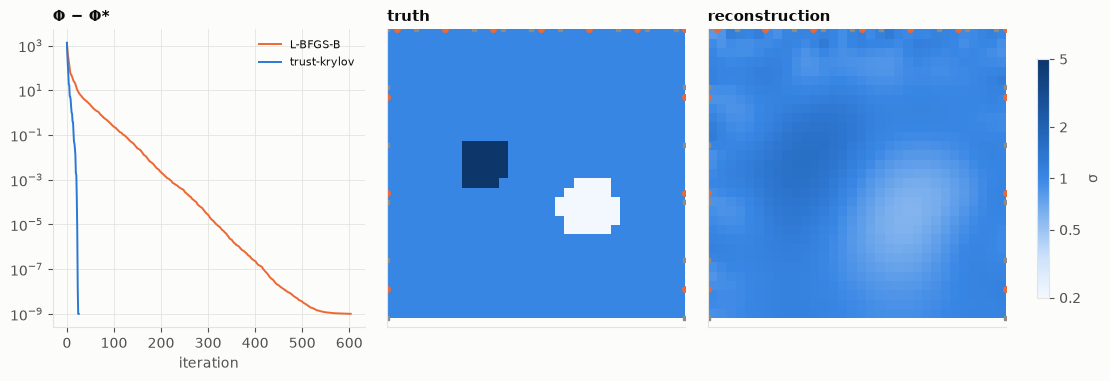

In [6]:
fig = plt.figure(figsize=(11, 3.7))
ax0 = fig.add_subplot(1, 3, 1)
for method, color in (("L-BFGS-B", plotstyle.ORANGE), ("trust-krylov", plotstyle.BLUE)):
  h = np.array(history[method])
  ax0.semilogy(h - min(runs[m][0].fun for m in runs) + 1e-9, color=color, lw=1.4, label=method)
ax0.set_xlabel("iteration")
ax0.set_title("Φ − Φ*")
ax0.legend(fontsize=8)
for k, (values, title) in enumerate(((np.exp(M_TRUE), "truth"), (np.exp(m_hat), "reconstruction"))):
  ax = fig.add_subplot(1, 3, k + 2)
  image = ax.imshow(field(values), origin="lower", extent=(0, 1, 0, 1), cmap=plotstyle.BLUES, norm="log", vmin=0.2, vmax=5)
  ax.plot(*XY[ELECTRODES].T, "s", ms=3, color=plotstyle.NEUTRAL)
  ax.plot(*XY[SOURCES].T, "o", ms=4, color=plotstyle.ORANGE)
  ax.set_title(title)
  ax.grid(False)
  ax.set_xticks([])
  ax.set_yticks([])
bar = fig.colorbar(image, ax=fig.axes[1:], shrink=0.8, label="σ", ticks=[0.2, 0.5, 1, 2, 5])
bar.ax.set_yticklabels(["0.2", "0.5", "1", "2", "5"])
bar.ax.minorticks_off()
plt.show()

The reconstruction finds both inclusions in the right places, smoothed by the regularizer and
with the contrast underestimated. This is the usual picture for a diffusive imaging modality, where
boundary data carry little information about the deep interior.

## Where the time goes

Every evaluation factors one sparse matrix and solves for thirteen right-hand sides. The gradient
adds thirteen adjoint solves with the same factor, and a Hessian–vector product adds a few more.
The factorization's analysis, with its minimum-degree ordering and elimination tree, happened
once, when the graph was built.

In [7]:
def timed(fn, *args, repeat=20):
  fn(*args)
  start = time.perf_counter()
  for _ in range(repeat):
    fn(*args)
  return (time.perf_counter() - start) / repeat


fact = linalg.SparseLDL(assemble(m_s), name="probe")
st = fact.symbolic.stats()
print(f"K: {FREE} x {FREE}; ordering {fact.symbolic.method}, nnz(L) = {st['nnz_l']}, {st['update_lanes']} multiply-adds per factorization")
print(f"forward (factor + 13 solves): {1e3 * timed(forward, m_hat):.2f} ms")
print(f"Phi and gradient:             {1e3 * timed(objective, (m_hat, d_obs)):.2f} ms")
print(f"Hessian-vector product:       {1e3 * timed(hvp, (m_hat, d_obs, direction)):.2f} ms")
print(f"SciPy spsolve, forward only:  {1e3 * timed(reference_forward, m_hat):.2f} ms")

K: 992 x 992; ordering auto:mmd, nnz(L) = 10082, 97424 multiply-adds per factorization
forward (factor + 13 solves): 0.59 ms
Phi and gradient:             1.07 ms
Hessian-vector product:       3.29 ms


SciPy spsolve, forward only:  4.55 ms


## The generated C

The objective with its adjoint gradient is one C function. It can be linked into an optimizer
written in another language, or into an acquisition system that inverts each new frame of data.

In [8]:
module = write_module(objective, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB, workspace {module.workspace_size} doubles")

objective.c: 729 lines, 1333 kB, workspace 215714 doubles
